In [31]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.transforms as transforms

from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder 
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import (confusion_matrix, classification_report,
							accuracy_score, precision_score, recall_score, f1_score)

In [32]:
train=pd.read_csv("./data/preprocessedTrain.csv")
test=pd.read_csv("./data/preprocessedTest.csv")

In [33]:
# To fill nulls
# print(train.isnull().sum())
train['f_Header_b_payload_Ratio'] = train['f_Header_b_payload_Ratio'].replace(np.nan, train['f_Header_b_payload_Ratio'].max() + 1) 
train['b_Header_f_payload_Ratio'] = train['b_Header_f_payload_Ratio'].replace(np.nan, train['b_Header_f_payload_Ratio'].max() + 1) 
# print(train.isnull().sum())
test['f_Header_b_payload_Ratio'] = test['f_Header_b_payload_Ratio'].replace(np.nan, test['f_Header_b_payload_Ratio'].max() + 1) 
test['b_Header_f_payload_Ratio'] = test['b_Header_f_payload_Ratio'].replace(np.nan, test['b_Header_f_payload_Ratio'].max() + 1) 
train

,id.orig_p,id.resp_p,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,flow_pkts_per_sec,...,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,proto_icmp,proto_udp,f_Header_b_payload_Ratio,b_Header_f_payload_Ratio,bwd_payload_zero_flg,fwd_payload_zero_flg,Attack_type
0,0.832746,0.000321,0.0,2.665046e-10,0.000282,0.000504,0.000282,0.0,0.190476,0.190476,...,0.000977,0.0,0.000977,0.0,0.0,2.0,0.012785,1.0,0.0,DOS_SYN_Hping
1,0.715709,0.000321,0.0,2.665046e-10,0.000282,0.000504,0.000282,0.0,0.190476,0.190476,...,0.000977,0.0,0.000977,0.0,0.0,2.0,0.012785,1.0,0.0,DOS_SYN_Hping
2,0.922972,0.000321,0.0,2.132037e-10,0.000282,0.000504,0.000282,0.0,0.250000,0.250000,...,0.000977,0.0,0.000977,0.0,0.0,2.0,0.012785,1.0,0.0,DOS_SYN_Hping
3,0.570230,0.000321,0.0,5.330092e-11,0.000282,0.000504,0.000282,0.0,1.000000,1.000000,...,0.000977,0.0,0.000977,0.0,0.0,2.0,0.012785,1.0,0.0,DOS_SYN_Hping
4,0.778759,0.093731,0.0,3.198055e-10,0.000282,0.000504,0.000000,0.0,0.160000,0.160000,...,0.015625,0.0,0.015625,0.0,0.0,2.0,2.000000,1.0,1.0,NMAP_OS_DETECTION
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98488,0.063005,0.000321,0.0,1.599028e-10,0.000282,0.000504,0.000282,0.0,0.307692,0.307692,...,0.000977,0.0,0.000977,0.0,0.0,2.0,0.012785,1.0,0.0,DOS_SYN_Hping
98489,0.117723,0.000321,0.0,2.132037e-10,0.000282,0.000504,0.000282,0.0,0.235294,0.235294,...,0.000977,0.0,0.000977,0.0,0.0,2.0,0.012785,1.0,0.0,DOS_SYN_Hping
98490,0.413428,0.000321,0.0,2.132037e-10,0.000282,0.000504,0.000282,0.0,0.235294,0.235294,...,0.000977,0.0,0.000977,0.0,0.0,2.0,0.012785,1.0,0.0,DOS_SYN_Hping
98491,0.126421,0.000321,0.0,2.665046e-10,0.000282,0.000504,0.000282,0.0,0.190476,0.190476,...,0.000977,0.0,0.000977,0.0,0.0,2.0,0.012785,1.0,0.0,DOS_SYN_Hping


In [34]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Train class counts:\n", train["Attack_type"].value_counts())
print("Test class counts:\n", test["Attack_type"].value_counts())

Train shape: (98493, 83)
Test shape: (24624, 83)
Train class counts:
 Attack_type
DOS_SYN_Hping                 75727
Thing_Speak                    6486
ARP_poisioning                 6200
MQTT_Publish                   3317
NMAP_UDP_SCAN                  2072
NMAP_XMAS_TREE_SCAN            1608
NMAP_OS_DETECTION              1600
NMAP_TCP_scan                   802
DDOS_Slowloris                  427
Wipro_bulb                      202
Metasploit_Brute_Force_SSH       30
NMAP_FIN_SCAN                    22
Name: count, dtype: int64
Test class counts:
 Attack_type
DOS_SYN_Hping                 18932
Thing_Speak                    1622
ARP_poisioning                 1550
MQTT_Publish                    829
NMAP_UDP_SCAN                   518
NMAP_XMAS_TREE_SCAN             402
NMAP_OS_DETECTION               400
NMAP_TCP_scan                   200
DDOS_Slowloris                  107
Wipro_bulb                       51
Metasploit_Brute_Force_SSH        7
NMAP_FIN_SCAN                   

# Multi-Class Classification Model

In [35]:
# Multi class classification
label_encoder = LabelEncoder()
label_encoder.fit(train["Attack_type"])

y_train = label_encoder.transform(train["Attack_type"])
y_test = label_encoder.transform(test["Attack_type"])

# Get class names for later
class_names = label_encoder.classes_
print(f"Number of classes: {len(class_names)}")
print(f"Classes: {class_names}")

X_train = train.drop("Attack_type", axis=1).values
X_test = test.drop("Attack_type", axis=1).values

Number of classes: 12
Classes: ['ARP_poisioning' 'DDOS_Slowloris' 'DOS_SYN_Hping' 'MQTT_Publish'
 'Metasploit_Brute_Force_SSH' 'NMAP_FIN_SCAN' 'NMAP_OS_DETECTION'
 'NMAP_TCP_scan' 'NMAP_UDP_SCAN' 'NMAP_XMAS_TREE_SCAN' 'Thing_Speak'
 'Wipro_bulb']


In [36]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [37]:
X_train_tensor = torch.tensor(X_train_res, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_res, dtype=torch.long) 

# TEST
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long) 

In [38]:
X_train_tensor = X_train_tensor.unsqueeze(1)
X_test_tensor = X_test_tensor.unsqueeze(1)
 
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)


train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)

In [39]:
x, y = next(iter(train_loader))
x.shape
print(X_train_tensor.shape)

torch.Size([908724, 1, 82])


In [ ]:
# input data format (batch_size, sequence_length, num_features)
# (batch, 1, 82) 
# the sequence represents temporal ordering...this would exist in real-time situation
class MultiClass1dCNN(nn.Module):
    def __init__(self, num_features=82, num_classes=12, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.conv1 = nn.Conv1d(in_channels=1,out_channels=16,kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(16)
        self.conv2 = nn.Conv1d(in_channels=16,out_channels=32,kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(32)
        self.pool = nn.MaxPool1d(2)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(32*(num_features//2),128)
        self.dropout = nn.Dropout1d(.2)
        self.fc2 = nn.Linear(128,num_classes)

    def forward(self,x):
        # convolutions
        x = self.pool(F.relu(self.bn2(self.conv2(F.relu(self.bn1(self.conv1(x)))))))
        # dense layers
        x = self.fc2(self.dropout(F.relu(self.fc1(F.relu(self.flatten(x))))))
        # output
        return x

In [47]:
model = MultiClass1dCNN()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [48]:
num_epochs = 5
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    total_loss = 0.0
    print("start epcoh")

    for batch, (X_batch, y_batch) in enumerate(train_loader):
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        running_loss += loss.item()
        total_loss+=loss.item()

        if (batch+1) % 500 == 0:
            print(f"[{epoch+1}, {batch+1}] loss: {running_loss/500:.4f}")
            running_loss = 0.0


    avg_loss = total_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{num_epochs}], Avg Loss: {avg_loss:.4f}")

start epcoh
[1, 500] loss: 0.6820
[1, 1000] loss: 0.5836
[1, 1500] loss: 0.5686
[1, 2000] loss: 0.5470
[1, 2500] loss: 0.5584
[1, 3000] loss: 0.5478
[1, 3500] loss: 0.5397
[1, 4000] loss: 0.5445
[1, 4500] loss: 0.5524
[1, 5000] loss: 0.5491
[1, 5500] loss: 0.5423
[1, 6000] loss: 0.5352
[1, 6500] loss: 0.5359
[1, 7000] loss: 0.5358
[1, 7500] loss: 0.5287
[1, 8000] loss: 0.5329
[1, 8500] loss: 0.5194
[1, 9000] loss: 0.5266
[1, 9500] loss: 0.5278
[1, 10000] loss: 0.5358
[1, 10500] loss: 0.5329
[1, 11000] loss: 0.5193
[1, 11500] loss: 0.5127
[1, 12000] loss: 0.5079
[1, 12500] loss: 0.5273
[1, 13000] loss: 0.5193
[1, 13500] loss: 0.5150
[1, 14000] loss: 0.5216
Epoch [1/5], Avg Loss: 0.5407
start epcoh
[2, 500] loss: 0.5191
[2, 1000] loss: 0.5228
[2, 1500] loss: 0.5220
[2, 2000] loss: 0.5147
[2, 2500] loss: 0.5327
[2, 3000] loss: 0.5219
[2, 3500] loss: 0.5214
[2, 4000] loss: 0.5225
[2, 4500] loss: 0.5260
[2, 5000] loss: 0.5237
[2, 5500] loss: 0.5199
[2, 6000] loss: 0.5243
[2, 6500] loss: 0.5

In [50]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

print(confusion_matrix(all_labels, all_preds))
print(classification_report(all_labels, all_preds, target_names=class_names))


[[ 1479     1     0     0     7     3     0     0     1     0    18    41]
 [    0   106     0     0     1     0     0     0     0     0     0     0]
 [    0     0 18932     0     0     0     0     0     0     0     0     0]
 [    1     0     0   825     0     0     0     0     0     0     0     3]
 [    0     0     0     0     7     0     0     0     0     0     0     0]
 [    0     0     0     0     0     0     0     0     1     0     0     5]
 [    0     0     0     0     0     0     0     0     0     0     0   400]
 [    0     0     0     0     0     0     0     0     0     0     0   200]
 [    2    14     0     0     1     0     0     0   197     0     0   304]
 [    0     0     0     0     0     1     0     0     1     0     0   400]
 [   17     2     0     0     0     2     0     0     1     0  1595     5]
 [    0     0     0     0     0     0     0     0     0     0     0    51]]
                            precision    recall  f1-score   support

            ARP_poisioning    

c:\Users\willo_jlqcl0r\miniconda3\envs\caps\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\willo_jlqcl0r\miniconda3\envs\caps\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\willo_jlqcl0r\miniconda3\envs\caps\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

In [53]:
acc = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds, average='weighted')
rec = recall_score(all_labels, all_preds, average='weighted')
f1 = f1_score(all_labels, all_preds, average='weighted')


print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))
print(f"\nOverall Metrics:")
print(f"Accuracy: {acc:.4f}")
print(f"Weighted Precision: {prec:.4f}")
print(f"Weighted Recall: {rec:.4f}")
print(f"Weighted F1 Score: {f1:.4f}")


Classification Report:
                            precision    recall  f1-score   support

            ARP_poisioning       0.99      0.95      0.97      1550
            DDOS_Slowloris       0.86      0.99      0.92       107
             DOS_SYN_Hping       1.00      1.00      1.00     18932
              MQTT_Publish       1.00      1.00      1.00       829
Metasploit_Brute_Force_SSH       0.44      1.00      0.61         7
             NMAP_FIN_SCAN       0.00      0.00      0.00         6
         NMAP_OS_DETECTION       0.00      0.00      0.00       400
             NMAP_TCP_scan       0.00      0.00      0.00       200
             NMAP_UDP_SCAN       0.98      0.38      0.55       518
       NMAP_XMAS_TREE_SCAN       0.00      0.00      0.00       402
               Thing_Speak       0.99      0.98      0.99      1622
                Wipro_bulb       0.04      1.00      0.07        51

                  accuracy                           0.94     24624
                 macro

c:\Users\willo_jlqcl0r\miniconda3\envs\caps\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\willo_jlqcl0r\miniconda3\envs\caps\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\willo_jlqcl0r\miniconda3\envs\caps\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

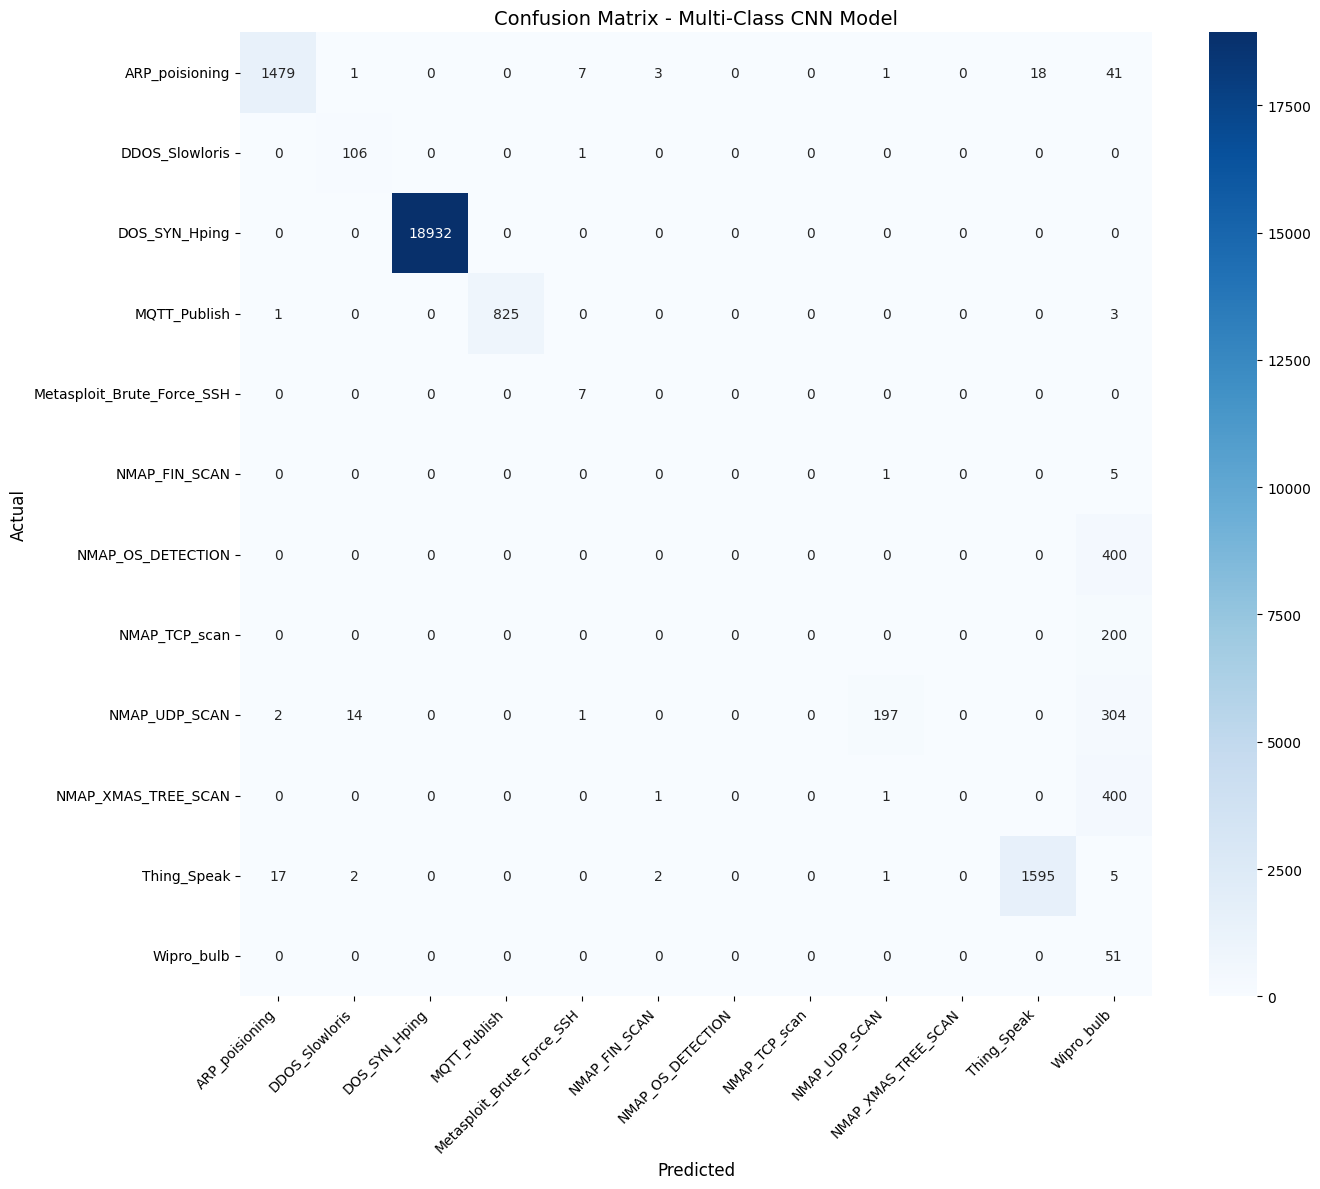

In [51]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted", fontsize=12)
plt.ylabel("Actual", fontsize=12)
plt.title("Confusion Matrix - Multi-Class CNN Model", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [52]:
torch.save(model.state_dict(), "models/1dcnn_multiclass.pth")
print("Model saved to models/1dcnn_multiclass.pth")

Model saved to models/1dcnn_multiclass.pth
